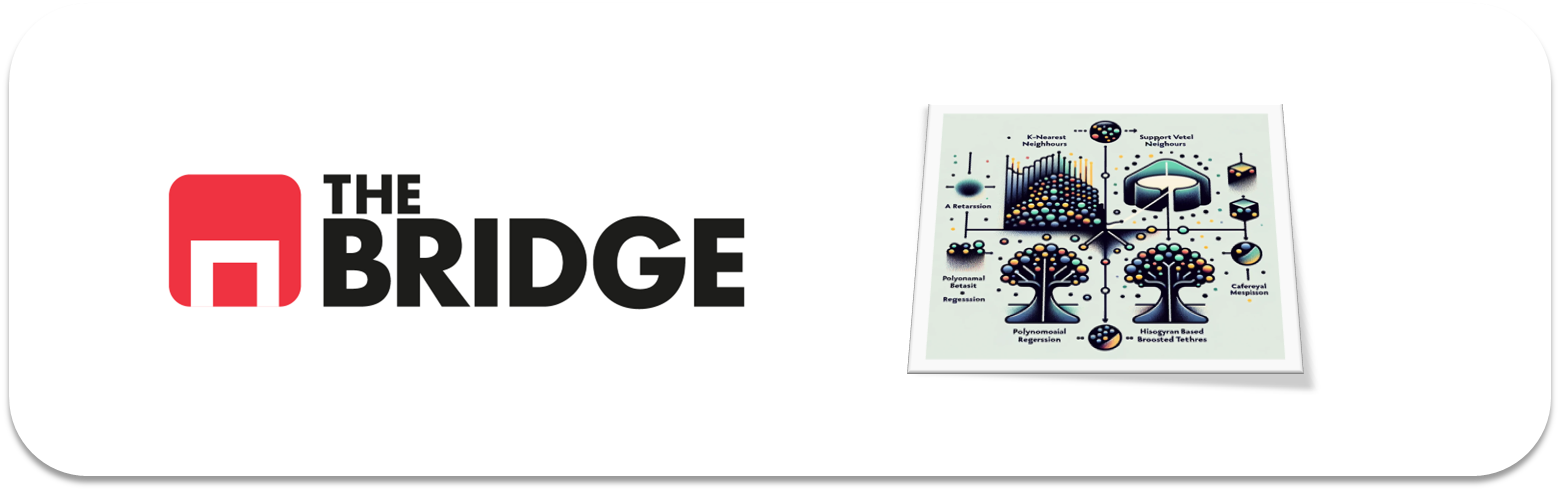

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_percentage_error
)

from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor
)

from sklearn.linear_model import (
    LogisticRegression,
    LinearRegression
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor
)

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [4]:
df = pd.read_csv("./data/wines_dataset.csv", sep="|")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [5]:
print("Dimensiones del dataset:", df.shape)
print()

df.info()

Dimensiones del dataset: (6497, 13)

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


### 1.1 — Distribución del target de clasificación: `quality`

Comenzamos analizando la distribución de `quality`, variable objetivo del problema de clasificación, para conocer las clases existentes y comprobar si presentan una distribución equilibrada.

In [6]:
print(df["quality"].value_counts().sort_index())
print()
print((df["quality"].value_counts(normalize=True).sort_index() * 100).round(2))

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

quality
3     0.46
4     3.32
5    32.91
6    43.65
7    16.61
8     2.97
9     0.08
Name: proportion, dtype: float64


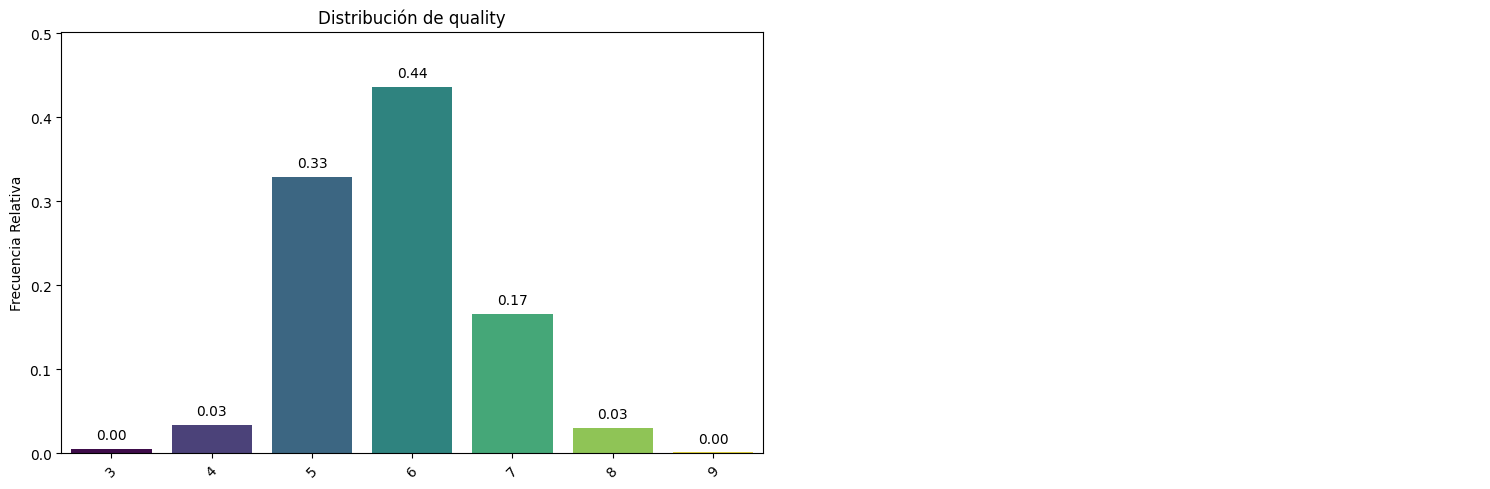

In [ ]:
bt.pinta_distribucion_categoricas(
    df,
    ["quality"],
    mostrar_valores=True,
    relativa=True
)

#### Assessment previo — Clasificación

La variable `quality` presenta **7 clases**, con valores comprendidos entre 3 y 9.

La distribución está claramente desbalanceada: las clases **5 y 6 concentran aproximadamente el 76.56 % de las observaciones**, mientras que las calidades extremas presentan muy pocos registros.

Por tanto, nos encontramos ante un problema de **clasificación multiclase con desbalanceo**, aspecto que tendremos que tener en cuenta durante el modelado y especialmente al seleccionar las métricas de evaluación.

### 1.2 — Distribución del target de regresión: `alcohol`

Analizamos la distribución de `alcohol`, variable objetivo del problema de regresión, para conocer su rango, tendencia central y forma de distribución.

In [9]:
print(df["alcohol"].describe().round(2))

count    6497.00
mean       10.49
std         1.19
min         8.00
25%         9.50
50%        10.30
75%        11.30
max        14.90
Name: alcohol, dtype: float64


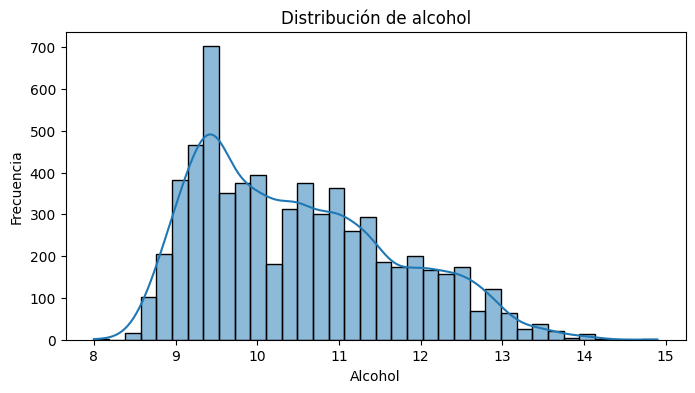

In [10]:
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="alcohol",
    kde=True
)

plt.title("Distribución de alcohol")
plt.xlabel("Alcohol")
plt.ylabel("Frecuencia")
plt.show()

#### Assessment previo — Regresión

La variable `alcohol` es una variable numérica continua, con valores comprendidos entre **8.0 y 14.9**, una media de **10.49** y una mediana de **10.30**.

La mayor parte de las observaciones se concentra aproximadamente entre valores de **9 y 12**, mostrando una distribución con cierta asimetría hacia la derecha.

Por tanto, nos encontramos ante un problema de **regresión**, en el que el objetivo será predecir el valor de `alcohol`. La distribución no presenta a priori valores extremos que requieran un tratamiento específico antes del modelado.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

### 2.1 — Preparación de los datos para clasificación

El objetivo del problema de clasificación será predecir la variable `quality` a partir de las características disponibles de cada vino.

Antes de realizar la separación entre Train y Test, revisamos la variable `class` para decidir cómo incorporarla al modelado.

In [11]:
print(df["class"].value_counts())
print()
print((df["class"].value_counts(normalize=True) * 100).round(2))

class
white    4898
red      1599
Name: count, dtype: int64

class
white    75.39
red      24.61
Name: proportion, dtype: float64


#### Tratamiento de la variable `class`

La variable `class` identifica el tipo de vino y presenta dos categorías: `white` y `red`.

Como puede aportar información relevante para predecir la calidad del vino, se mantendrá como variable predictora. Al tratarse de una variable categórica binaria, la transformaremos a valores numéricos para poder utilizarla durante el modelado.

In [12]:
df_model = df.copy()

df_model["class"] = df_model["class"].map({
    "white": 0,
    "red": 1
})

print(df_model["class"].value_counts())

class
0    4898
1    1599
Name: count, dtype: int64


### 2.2 — Separación en Train y Test

Definimos `quality` como variable objetivo y utilizamos el resto de variables como predictoras.

Realizamos la separación entre Train y Test utilizando `stratify=y` para mantener la distribución de las distintas clases de `quality` en ambos conjuntos.

In [13]:
x = df_model.drop(columns="quality")
y = df_model["quality"]

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (5197, 12)
Test: (1300, 12)


In [14]:
print("Distribución en Train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nDistribución en Test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

Distribución en Train:
quality
3     0.46
4     3.33
5    32.90
6    43.66
7    16.61
8     2.96
9     0.08
Name: proportion, dtype: float64

Distribución en Test:
quality
3     0.46
4     3.31
5    32.92
6    43.62
7    16.62
8     3.00
9     0.08
Name: proportion, dtype: float64


#### Resultado de la separación Train/Test

La estratificación ha permitido mantener prácticamente la misma distribución de las clases de `quality` en los conjuntos de Train y Test.

Esto es especialmente importante debido al desbalanceo existente entre las distintas clases y nos permite disponer de un conjunto de Test representativo para la evaluación final del modelo.

### 2.3 — Escalado de las variables

KNN es un algoritmo basado en distancias, por lo que puede verse afectado cuando las variables presentan escalas diferentes.

Por este motivo, estandarizamos las variables predictoras utilizando `StandardScaler`. El escalador se ajusta únicamente con los datos de Train y posteriormente se aplica a Test, evitando así utilizar información del conjunto de prueba durante el entrenamiento.

In [15]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Media Train:", x_train_scaled.mean().round(2))
print("Desviación estándar Train:", x_train_scaled.std().round(2))
print("Shape Train:", x_train_scaled.shape)
print("Shape Test:", x_test_scaled.shape)

Media Train: -0.0
Desviación estándar Train: 1.0
Shape Train: (5197, 12)
Shape Test: (1300, 12)


#### Resultado del escalado

La estandarización se ha realizado correctamente. Las variables de Train presentan una media aproximadamente igual a **0** y una desviación estándar igual a **1**.

Los conjuntos mantienen sus dimensiones originales, por lo que podemos comenzar el modelado con KNN.

### 2.4 — KNN como modelo baseline

Utilizamos KNN como modelo baseline y probamos inicialmente dos valores del hiperparámetro `K`: **3 y 5**.

Para comparar su rendimiento utilizamos validación cruzada con `balanced_accuracy`, métrica que permite evaluar el recall medio de las distintas clases y resulta especialmente adecuada teniendo en cuenta el desbalanceo observado en `quality`.

In [22]:
cv_clf = StratifiedKFold(
    n_splits=4,
    shuffle=True,
    random_state=42
)

In [23]:
scores_knn_3 = cross_val_score(
    knn_3,
    x_train_scaled,
    y_train,
    cv=cv_clf,
    scoring="balanced_accuracy"
)

scores_knn_5 = cross_val_score(
    knn_5,
    x_train_scaled,
    y_train,
    cv=cv_clf,
    scoring="balanced_accuracy"
)

print("KNN K=3:", scores_knn_3.mean().round(4))
print("KNN K=5:", scores_knn_5.mean().round(4))

KNN K=3: 0.2983
KNN K=5: 0.2731


#### Resultado del modelo baseline KNN

Tras evaluar dos valores de `K` mediante validación cruzada estratificada, KNN obtiene una `balanced_accuracy` media de **0.2983 con K=3** y **0.2731 con K=5**.

Por tanto, **K=3 presenta el mejor rendimiento de los dos valores evaluados** y se utilizará como referencia para comparar los siguientes modelos.

El valor relativamente bajo del recall medio puede estar relacionado con el fuerte desbalanceo existente entre las clases de `quality`, especialmente en las calidades menos frecuentes.

### 2.5 — Regresión Logística

Como segundo modelo evaluamos una Regresión Logística multiclase.

Utilizamos las variables escaladas y mantenemos `balanced_accuracy` como métrica de comparación, junto con la misma estrategia de validación cruzada utilizada para KNN.

In [25]:
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

scores_log_reg = cross_val_score(
    log_reg,
    x_train_scaled,
    y_train,
    cv=cv_clf,
    scoring="balanced_accuracy"
)

print("KNN K=3:", scores_knn_3.mean().round(4))
print("Regresión Logística:", scores_log_reg.mean().round(4))

KNN K=3: 0.2983
Regresión Logística: 0.229


#### Resultado de Regresión Logística

La Regresión Logística obtiene una `balanced_accuracy` media de **0.2290**, inferior al **0.2983** obtenido por KNN con `K=3`.

Por tanto, la Regresión Logística no mejora el modelo baseline y, hasta el momento, **KNN con K=3 continúa siendo la mejor alternativa** de las evaluadas.

### 2.6 — Random Forest

Como tercer modelo evaluamos un `RandomForestClassifier`.

A diferencia de KNN y Regresión Logística, Random Forest no requiere el escalado previo de las variables, por lo que utilizaremos directamente los datos de Train sin estandarizar.

Mantenemos la misma validación cruzada y `balanced_accuracy` como métrica para poder comparar los modelos bajo el mismo criterio.

In [26]:
rf = RandomForestClassifier(
    random_state=42
)

scores_rf = cross_val_score(
    rf,
    x_train,
    y_train,
    cv=cv_clf,
    scoring="balanced_accuracy"
)

print("KNN K=3:", scores_knn_3.mean().round(4))
print("Regresión Logística:", scores_log_reg.mean().round(4))
print("Random Forest:", scores_rf.mean().round(4))

KNN K=3: 0.2983
Regresión Logística: 0.229
Random Forest: 0.3402


#### Resultado de Random Forest

Random Forest obtiene una `balanced_accuracy` media de **0.3402**, superando tanto a KNN con `K=3` (**0.2983**) como a Regresión Logística (**0.2290**).

Por tanto, **Random Forest presenta hasta el momento el mejor rendimiento** de los tres modelos evaluados.

No obstante, el recall medio continúa siendo relativamente bajo, por lo que antes de seleccionar definitivamente el modelo evaluaremos alguna estrategia para mejorar el tratamiento del desbalanceo entre las clases.

### 2.7 — Tratamiento del desbalanceo de clases

Debido al fuerte desbalanceo observado en `quality`, probamos una versión de Random Forest utilizando `class_weight="balanced"`.

Esta opción asigna automáticamente un mayor peso a las clases menos frecuentes durante el entrenamiento. Evaluamos nuevamente el modelo mediante validación cruzada y `balanced_accuracy` para comprobar si mejora el recall medio respecto al Random Forest original.

In [27]:
rf_balanced = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

scores_rf_balanced = cross_val_score(
    rf_balanced,
    x_train,
    y_train,
    cv=cv_clf,
    scoring="balanced_accuracy"
)

print("Random Forest original:", scores_rf.mean().round(4))
print("Random Forest balanced:", scores_rf_balanced.mean().round(4))

Random Forest original: 0.3402
Random Forest balanced: 0.338


#### Resultado del tratamiento del desbalanceo

La aplicación de `class_weight="balanced"` no mejora el rendimiento del modelo. El Random Forest original obtiene una `balanced_accuracy` de **0.3402**, frente a **0.3380** del modelo balanceado.

Aunque la diferencia es pequeña, el modelo original continúa presentando el mejor recall medio. Por tanto, descartamos esta estrategia de balanceo y mantenemos **Random Forest sin `class_weight`** como el mejor modelo hasta el momento.

### 2.8 — Optimización de hiperparámetros de Random Forest

Tras comparar los modelos y evaluar el uso de `class_weight`, seleccionamos Random Forest como el modelo con mejor rendimiento.

A continuación utilizamos `GridSearchCV` para buscar una combinación de hiperparámetros que permita mejorar su `balanced_accuracy`, manteniendo la misma estrategia de validación cruzada utilizada anteriormente.

In [28]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="balanced_accuracy",
    cv=cv_clf,
    n_jobs=-1
)

grid_rf.fit(x_train, y_train)

print("Mejores parámetros:", grid_rf.best_params_)
print("Mejor balanced accuracy:", round(grid_rf.best_score_, 4))

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Mejor balanced accuracy: 0.3403


#### Resultado de la optimización

La optimización mediante `GridSearchCV` selecciona un Random Forest con **200 estimadores**, sin límite de profundidad (`max_depth=None`) y `min_samples_split=2`.

El modelo optimizado obtiene una `balanced_accuracy` de **0.3403**, frente al **0.3402** del modelo original.

La mejora es prácticamente inexistente, por lo que podemos concluir que, dentro del espacio de hiperparámetros evaluado, el modelo inicial ya presentaba una configuración cercana a la mejor encontrada.

### 2.9 — Evaluación del modelo seleccionado en Test

Una vez seleccionado y optimizado el modelo, evaluamos su rendimiento sobre el conjunto de Test utilizando el `classification_report`.

In [29]:
best_rf = grid_rf.best_estimator_

y_pred = best_rf.predict(x_test)

print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.71      0.12      0.20        43
           5       0.73      0.74      0.74       428
           6       0.64      0.77      0.70       567
           7       0.66      0.51      0.57       216
           8       0.93      0.33      0.49        39
           9       0.00      0.00      0.00         1

    accuracy                           0.68      1300
   macro avg       0.53      0.35      0.39      1300
weighted avg       0.68      0.68      0.67      1300



#### Resultado de la evaluación en Test

El modelo final obtiene una **accuracy de 0.68** y un **recall medio (macro avg) de 0.35**, resultado coherente con la `balanced_accuracy` obtenida durante la validación cruzada.

El modelo presenta un mejor rendimiento en las clases mayoritarias, especialmente para las calidades **5 y 6**, con recalls de **0.74 y 0.77**, respectivamente.

Sin embargo, presenta dificultades para identificar las clases menos frecuentes. Las calidades **3 y 9 no son detectadas**, mientras que la calidad **4 obtiene un recall de solo 0.12**.

Estos resultados muestran que el fuerte desbalanceo de la variable objetivo continúa siendo una de las principales limitaciones del modelo.

### 2.10 — Análisis de errores

Para analizar con mayor detalle los errores del modelo representamos la matriz de confusión normalizada por clase real. Esto nos permitirá observar qué proporción de cada calidad es clasificada correctamente y con qué otras clases se producen las principales confusiones.

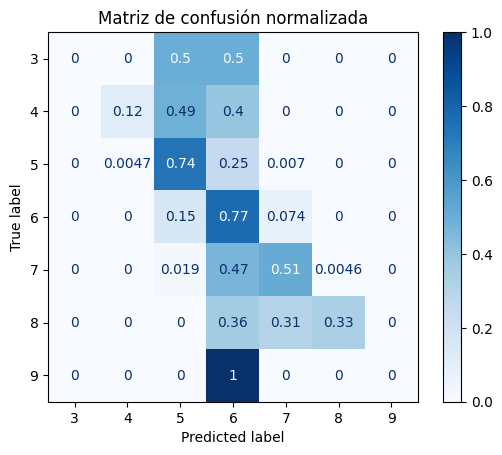

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    normalize="true",
    cmap="Blues"
)

plt.title("Matriz de confusión normalizada")
plt.show()

#### Análisis de errores

La matriz de confusión confirma que el modelo presenta un mejor comportamiento en las clases mayoritarias **5 y 6**, que alcanzan aproximadamente un **74 % y 77 % de predicciones correctas**, respectivamente.

Los principales errores se producen entre clases de calidad cercanas. Por ejemplo, aproximadamente un **25 % de los vinos de calidad 5 se clasifican como 6**, mientras que cerca del **47 % de los vinos de calidad 7 se clasifican como 6**.

Las mayores dificultades aparecen en las clases extremas y menos representadas. El modelo no consigue identificar correctamente ningún vino de calidad **3 ni 9**, y la calidad **4** presenta únicamente un **12 % de aciertos**.

En general, el modelo muestra una tendencia a concentrar sus predicciones en las clases centrales, especialmente en las calidades **5 y 6**, lo que refleja el efecto del fuerte desbalanceo existente en la variable objetivo.

### 2.11 — Propuesta de mejora

Una posible mejora sería reformular el problema agrupando las puntuaciones de calidad en un número menor de categorías, por ejemplo **calidad baja, media y alta**.

Las clases extremas disponen de muy pocas observaciones, lo que dificulta que el modelo pueda aprender patrones suficientemente representativos para distinguirlas. Además, la matriz de confusión muestra que gran parte de los errores se producen entre puntuaciones cercanas.

Otra posibilidad sería disponer de un mayor número de observaciones pertenecientes a las clases minoritarias o estudiar técnicas adicionales de balanceo.

Esta reformulación podría reducir el efecto del fuerte desbalanceo y facilitar la identificación de distintos niveles de calidad.

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

### 3.1 — Preparación de los datos para regresión

En esta segunda parte utilizaremos `alcohol` como variable objetivo, por lo que nos encontramos ante un problema de regresión.

Reutilizamos la preparación realizada anteriormente, incluyendo la transformación numérica de la variable `class`.

Para mantener la misma separación entre Train y Test utilizaremos los índices obtenidos en el problema de clasificación. En este caso, `quality` pasa a formar parte de las variables predictoras, tal como establece el enunciado.

In [31]:
train_reg = df_model.loc[x_train.index]
test_reg = df_model.loc[x_test.index]

x_train_reg = train_reg.drop(columns="alcohol")
y_train_reg = train_reg["alcohol"]

x_test_reg = test_reg.drop(columns="alcohol")
y_test_reg = test_reg["alcohol"]

print("Train:", x_train_reg.shape)
print("Test:", x_test_reg.shape)

print("\nVariables predictoras:")
print(x_train_reg.columns.tolist())

Train: (5197, 12)
Test: (1300, 12)

Variables predictoras:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'quality', 'class']


#### Resultado de la preparación

Los conjuntos de Train y Test mantienen la misma separación utilizada anteriormente, con **5197 observaciones para entrenamiento** y **1300 para evaluación**.

Para el problema de regresión disponemos de **12 variables predictoras**, incluyendo las características fisicoquímicas del vino, su `class` y la puntuación `quality`. La variable `alcohol` se utiliza exclusivamente como variable objetivo.

### 3.2 — Comparación de modelos de regresión

Para predecir el grado alcohólico compararemos tres modelos de regresión: **Regresión Lineal, KNN Regressor y Random Forest Regressor**.

Utilizaremos **MAPE (Mean Absolute Percentage Error)** como métrica de comparación, ya que permite expresar el error medio de las predicciones en términos relativos.

La comparación se realizará mediante validación cruzada antes de seleccionar y optimizar el modelo con mejor rendimiento.

### 3.3 — Escalado de las variables

Para poder evaluar KNN Regressor estandarizamos las variables predictoras, ya que este modelo se basa en distancias y puede verse afectado por las diferencias de escala entre las variables.

El escalador se ajusta únicamente con los datos de Train y posteriormente se aplica al conjunto de Test.

In [33]:
scaler_reg = StandardScaler()

x_train_reg_scaled = scaler_reg.fit_transform(x_train_reg)
x_test_reg_scaled = scaler_reg.transform(x_test_reg)

print("Media Train:", x_train_reg_scaled.mean().round(2))
print("Desviación estándar Train:", x_train_reg_scaled.std().round(2))
print("Shape Train:", x_train_reg_scaled.shape)
print("Shape Test:", x_test_reg_scaled.shape)

Media Train: -0.0
Desviación estándar Train: 1.0
Shape Train: (5197, 12)
Shape Test: (1300, 12)


#### Resultado del escalado

La estandarización se ha realizado correctamente. Las variables de Train presentan una media aproximadamente igual a **0** y una desviación estándar igual a **1**.

Los conjuntos mantienen sus dimensiones originales, por lo que los datos están preparados para comenzar la comparación de los modelos de regresión.

### 3.4 — Validación cruzada de los modelos de regresión

Evaluamos mediante validación cruzada los tres modelos seleccionados utilizando MAPE como métrica de comparación.

Como `cross_val_score` devuelve el MAPE con signo negativo, transformaremos los resultados a valores positivos para facilitar su interpretación. En esta métrica, **un valor menor indica un mejor rendimiento**.

In [34]:
lin_reg = LinearRegression()
knn_reg = KNeighborsRegressor(n_neighbors=5)
rf_reg = RandomForestRegressor(random_state=42)

scores_lin = -cross_val_score(
    lin_reg,
    x_train_reg_scaled,
    y_train_reg,
    cv=5,
    scoring="neg_mean_absolute_percentage_error"
)

scores_knn = -cross_val_score(
    knn_reg,
    x_train_reg_scaled,
    y_train_reg,
    cv=5,
    scoring="neg_mean_absolute_percentage_error"
)

scores_rf_reg = -cross_val_score(
    rf_reg,
    x_train_reg,
    y_train_reg,
    cv=5,
    scoring="neg_mean_absolute_percentage_error"
)

print("Regresión Lineal:", scores_lin.mean().round(4))
print("KNN Regressor:", scores_knn.mean().round(4))
print("Random Forest:", scores_rf_reg.mean().round(4))

Regresión Lineal: 0.0342
KNN Regressor: 0.0419
Random Forest: 0.0261


#### Resultado de la comparación de modelos

Los tres modelos presentan errores relativamente bajos, aunque existen diferencias entre ellos.

La Regresión Lineal obtiene un MAPE medio de **0.0342 (3.42 %)**, mientras que KNN Regressor presenta el peor resultado con **0.0419 (4.19 %)**.

Random Forest obtiene el menor error, con un MAPE medio de **0.0261 (2.61 %)**.

Por tanto, **Random Forest Regressor es el modelo seleccionado**, ya que presenta el mejor rendimiento durante la validación cruzada.

### 3.5 — Optimización de hiperparámetros

Tras comparar los tres modelos seleccionamos Random Forest Regressor por presentar el menor MAPE durante la validación cruzada.

A continuación utilizamos `GridSearchCV` para buscar una combinación de hiperparámetros que permita reducir el error de predicción del modelo.

In [35]:
param_grid_reg = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

grid_rf_reg = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid_reg,
    scoring="neg_mean_absolute_percentage_error",
    cv=5,
    n_jobs=-1
)

grid_rf_reg.fit(x_train_reg, y_train_reg)

print("Mejores parámetros:", grid_rf_reg.best_params_)
print("Mejor MAPE:", round(-grid_rf_reg.best_score_, 4))

Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Mejor MAPE: 0.026


#### Resultado de la optimización

La optimización selecciona un Random Forest con **200 árboles**, sin limitar la profundidad máxima y con `min_samples_split=2`.

El MAPE obtenido mediante validación cruzada es de aproximadamente **0.0260 (2.60 %)**, frente al **2.61 %** obtenido por el modelo inicial.

La mejora es muy pequeña, lo que indica que la configuración inicial del Random Forest ya ofrecía un rendimiento muy cercano al obtenido tras la optimización.

### 3.6 — Evaluación del modelo seleccionado

Evaluamos el Random Forest optimizado sobre el conjunto de Test, que no ha sido utilizado durante la selección ni la optimización del modelo.

Utilizaremos nuevamente MAPE para poder comparar su rendimiento con el obtenido durante la validación cruzada.

In [36]:
best_rf_reg = grid_rf_reg.best_estimator_

y_pred_reg = best_rf_reg.predict(x_test_reg)

mape_test = mean_absolute_percentage_error(
    y_test_reg,
    y_pred_reg
)

print("MAPE validación cruzada:",
      round(-grid_rf_reg.best_score_ * 100, 2), "%")

print("MAPE Test:",
      round(mape_test * 100, 2), "%")

MAPE validación cruzada: 2.6 %
MAPE Test: 2.55 %


#### Resultado de la evaluación

El modelo optimizado obtiene un **MAPE del 2.55 % en el conjunto de Test**, un resultado muy próximo al **2.60 % obtenido mediante validación cruzada**.

La similitud entre ambos resultados indica que el modelo mantiene un comportamiento estable sobre datos no utilizados durante el entrenamiento y presenta una buena capacidad de generalización.

En términos relativos, las predicciones del grado alcohólico presentan un error medio aproximado del **2.55 %** respecto a los valores reales.

### 3.7 — Análisis de errores

Para analizar el comportamiento del modelo comparamos los valores reales de alcohol con las predicciones realizadas sobre el conjunto de Test.

Cuanto más próximas se encuentren las observaciones a la línea diagonal, menor será la diferencia entre el valor real y el valor predicho.

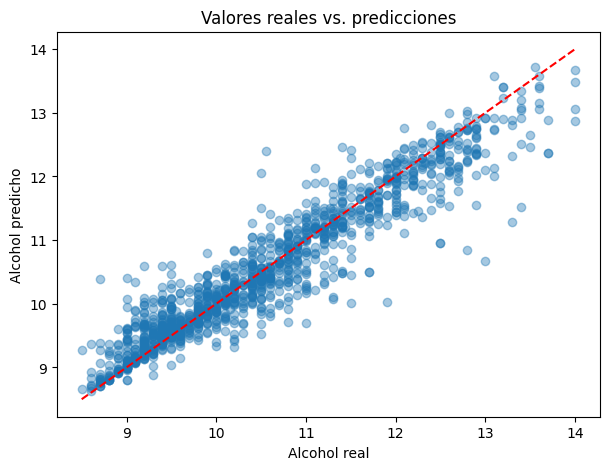

In [37]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test_reg,
    y_pred_reg,
    alpha=0.4
)

plt.plot(
    [y_test_reg.min(), y_test_reg.max()],
    [y_test_reg.min(), y_test_reg.max()],
    "r--"
)

plt.xlabel("Alcohol real")
plt.ylabel("Alcohol predicho")
plt.title("Valores reales vs. predicciones")

plt.show()

#### Interpretación de valores reales vs. predicciones

La mayoría de las predicciones se encuentran próximas a la línea diagonal, lo que indica una buena correspondencia entre los valores reales y los valores estimados por el modelo.

La dispersión es relativamente reducida en gran parte del rango de alcohol, aunque se observan algunos errores mayores especialmente en valores altos.

En conjunto, la gráfica es coherente con el bajo MAPE obtenido en Test y confirma que el modelo realiza predicciones razonablemente próximas a los valores reales.

count    1300.000
mean        0.011
std         0.398
min        -1.854
25%        -0.186
50%        -0.005
75%         0.178
max         2.334
Name: alcohol, dtype: float64


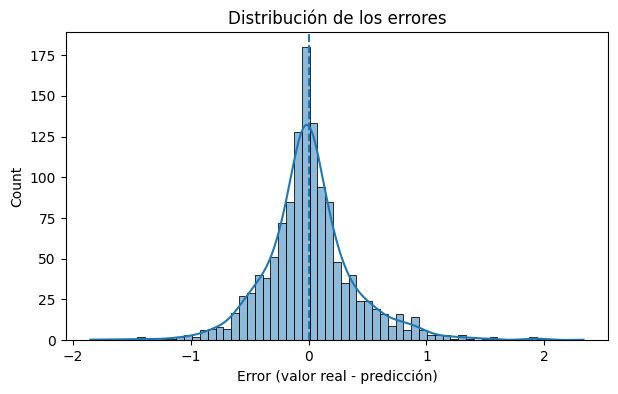

In [38]:
errores = y_test_reg - y_pred_reg

print(pd.Series(errores).describe().round(3))

plt.figure(figsize=(7, 4))
sns.histplot(errores, kde=True)

plt.axvline(0, linestyle="--")
plt.xlabel("Error (valor real - predicción)")
plt.title("Distribución de los errores")

plt.show()

#### Conclusión del análisis de errores

Los errores se encuentran fuertemente concentrados alrededor de **0**, con una media de **0.011** y una mediana de **-0.005**. Esto indica que el modelo no presenta una tendencia importante a sobreestimar o subestimar sistemáticamente el grado alcohólico.

Además, el 50 % central de los errores se encuentra aproximadamente entre **-0.186 y 0.178**, aunque existen algunas observaciones puntuales con errores mayores.

En conjunto, el análisis de errores, junto con el **MAPE del 2.55 % obtenido en Test**, indica que el Random Forest optimizado presenta un buen comportamiento para la predicción del grado alcohólico y mantiene un rendimiento estable sobre datos no utilizados durante el entrenamiento.